# FASE 5: Skenario C - Transfer Learning (EfficientNetB0) & Fine-Tuning
**Proyek Skripsi:** Klasifikasi Jenis Obat Tablet Menggunakan Convolutional Neural Network (CNN)

## Tujuan Notebook Ini:
1. Menggunakan arsitektur kelas dunia **EfficientNetB0** yang telah dilatih dengan jutaan gambar dari ImageNet.
2. Menerapkan teknik *Data Augmentation* yang sama dengan Skenario B.
3. Melakukan **Transfer Learning** (membekukan bobot dasar dan melatih lapisan klasifikasi baru).
4. Melakukan **Fine-Tuning** (membuka kunci beberapa lapisan terakhir dari EfficientNet untuk beradaptasi khusus pada fitur tablet obat) demi mencapai akurasi maksimal.
5. Menghasilkan artefak evaluasi akhir untuk dibandingkan dengan Skenario A dan B di BAB IV.

In [1]:
# Import library standar industri
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

# Hubungkan Google Drive
drive.mount('/content/drive')

print("✅ Library berhasil diimpor dan Google Drive terhubung.")

Mounted at /content/drive
✅ Library berhasil diimpor dan Google Drive terhubung.


## 1. Konfigurasi Parameter & Data Generator
Pada Skenario C, kita tidak lagi menggunakan `rescale=1./255`. Arsitektur EfficientNet memiliki standar prapemrosesan pikselnya sendiri. Oleh karena itu, kita menggunakan fungsi bawaan `preprocess_input` dari Keras. Transformasi augmentasi geometris tetap digunakan secara agresif.

In [2]:
# ==========================================
# KONFIGURASI DIREKTORI & HYPERPARAMETER
# ==========================================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB'
BASELINE_DIR = os.path.join(BASE_DIR, 'data', 'baseline_dataset')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs', 'scenario_c')

os.makedirs(OUTPUTS_DIR, exist_ok=True)

TARGET_CLASSES = [
    "cataflam_50_mg", "cetirizin_10_mg", "pantoprazol_sandoz_40_mg",
    "c_vitamin_teva_500_mg", "aspirin_ultra_500_mg",
    "algoflex_forte_dolo_400_mg", "merckformin_xr_1000_mg"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def create_efficientnet_generators():
    """
    Membuat data generator khusus untuk EfficientNet menggunakan preprocess_input bawaan.
    """
    # Generator Latih + Augmentasi
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generator Validasi & Test (MURNI)
    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    print("Memuat Data Latih (Train)...")
    train_gen = train_datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=True
    )

    print("Memuat Data Validasi (Validation)...")
    val_gen = val_test_datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'valid'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=False
    )

    print("Memuat Data Uji (Test)...")
    test_gen = val_test_datagen.flow_from_directory(
        os.path.join(BASELINE_DIR, 'test'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=TARGET_CLASSES,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

train_generator, val_generator, test_generator = create_efficientnet_generators()

Memuat Data Latih (Train)...
Found 196 images belonging to 7 classes.
Memuat Data Validasi (Validation)...
Found 42 images belonging to 7 classes.
Memuat Data Uji (Test)...
Found 42 images belonging to 7 classes.


## 2. Perancangan Arsitektur Transfer Learning
Kita mengunduh kerangka kerja EfficientNetB0.
Pada tahap pertama ini (Transfer Learning), seluruh lapisan (*layers*) dari EfficientNet kita **bekukan** (`trainable = False`). Kita hanya menambahkan lapisan klasifikasi (*Classifier Head*) baru di ujungnya untuk dilatih mengenali 7 kelas obat kita.

In [3]:
def build_transfer_learning_model(input_shape=(224, 224, 3), num_classes=7):
    """
    Membangun arsitektur Transfer Learning berbasis EfficientNetB0.
    """
    # Load model dasar tanpa lapisan klasifikasi teratas (include_top=False)
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

    # Bekukan seluruh bobot (freeze)
    base_model.trainable = False

    # Tambahkan lapisan klasifikasi kustom
    x = base_model.output
    x = GlobalAveragePooling2D()(x) # Meratakan fitur spasial
    x = Dropout(0.4)(x)             # Regularisasi
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

model_c, base_model_c = build_transfer_learning_model(num_classes=len(TARGET_CLASSES))
print(f"Total layers dalam arsitektur: {len(model_c.layers)}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers dalam arsitektur: 241


## 3. Training Tahap 1 (Warm-Up Classifier)
Melatih lapisan klasifikasi yang baru ditambahkan selama beberapa *epoch*. Tujuannya agar bobot baru tersebut stabil sebelum kita membedah bagian dalam EfficientNet.

In [4]:
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'scenario_c.h5')

# Callbacks standar
checkpoint = ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\n🚀 Memulai Tahap 1: Melatih Classifier Head...")
history_step1 = model_c.fit(
    train_generator,
    epochs=15, # Epoch kecil untuk pemanasan
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


🚀 Memulai Tahap 1: Melatih Classifier Head...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1530 - loss: 2.0342
Epoch 1: val_accuracy improved from None to 0.52381, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 127s 8s/step - accuracy: 0.1990 - loss: 1.9227 - val_accuracy: 0.5238 - val_loss: 1.5975
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.3006 - loss: 1.7218
Epoch 2: val_accuracy improved from 0.52381 to 0.66667, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.3571 - loss: 1.6718 - val_accuracy: 0.6667 - val_loss: 1.3638
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.4857 - loss: 1.4446
Epoch 3: val_accuracy improved from 0.66667 to 0.71429, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - accuracy: 0.5306 - loss: 1.4234 - val_accuracy: 0.7143 - val_loss: 1.1878
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6040 - loss: 1.2597
Epoch 4: val_accuracy did not improve from 0.71429
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step - accuracy: 0.6173 - loss: 1.2364 - val_accuracy: 0.7143 - val_loss: 1.0193
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6450 - loss: 1.1189
Epoch 5: val_accuracy did not improve from 0.71429
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.6837 - loss: 1.0988 - val_accuracy: 0.7143 - val_loss: 0.9557
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6593 - loss: 1.0816
Epoch 6: val_accuracy did not improve from 0.71429
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.6633 - loss: 1.0292 - val_accuracy: 0.6905 - val_loss: 0.8653
Epoch 7


Epoch 8: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 459ms/step - accuracy: 0.7398 - loss: 0.8585 - val_accuracy: 0.7381 - val_loss: 0.7168
Epoch 9/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.8442 - loss: 0.7232
Epoch 9: val_accuracy improved from 0.73810 to 0.78571, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.8367 - loss: 0.7393 - val_accuracy: 0.7857 - val_loss: 0.6893
Epoch 10/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8030 - loss: 0.7186
Epoch 10: val_accuracy did not improve from 0.78571
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.8061 - loss: 0.7138 - val_accuracy: 0.6667 - val_loss: 0.6786
Epoch 11/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8037 - loss: 0.6725
Epoch 11: val_accuracy did not improve from 0.78571
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.8061 - loss: 0.6651 - val_accuracy: 0.7857 - val_loss: 0.6225
Epoch 12/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8432 - loss: 0.6186
Epoch 12: val_accuracy improved from 0.78571 to 0.83333, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5



Epoch 12: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.8163 - loss: 0.6365 - val_accuracy: 0.8333 - val_loss: 0.5872
Epoch 13/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7855 - loss: 0.6781
Epoch 13: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.8265 - loss: 0.6193 - val_accuracy: 0.8095 - val_loss: 0.5772
Epoch 14/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8242 - loss: 0.6255
Epoch 14: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.8265 - loss: 0.6059 - val_accuracy: 0.8333 - val_loss: 0.5653
Epoch 15/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.8912 - loss: 0.5186
Epoch 15: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 332ms/step - accuracy: 0.8520 - loss: 0.5392 - val_accuracy: 0.8333 - val_loss: 0.5465


## 4. Training Tahap 2: Fine-Tuning (Senjata Pamungkas)
Untuk menembus akurasi ekstrem, kita membuka kunci (*unfreeze*) 20 lapisan terakhir dari EfficientNetB0. Lapisan ini akan dilatih ulang secara perlahan agar fiturnya benar-benar beradaptasi dengan *imprint* dan bentuk obat.

*Penting: Learning rate harus sangat kecil (misal `1e-5`) agar kita tidak merusak bobot cerdas bawaan ImageNet.*

In [5]:
def fine_tune_model(model, base_model, train_gen, val_gen):
    """
    Membuka lapisan dalam model dasar untuk dilatih spesifik pada data medis.
    """
    # Buka kunci base model
    base_model.trainable = True

    # Bekukan kembali lapisan bawah, biarkan 20 lapisan teratas terbuka
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    print(f"✅ Fine-Tuning aktif pada 20 lapisan teratas.")

    # Re-compile dengan learning rate SANGAT KECIL
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Tambahkan Scheduler agar LR turun jika model kesulitan belajar
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    print("\n🚀 Memulai Tahap 2: Fine-Tuning...")
    history_step2 = model.fit(
        train_gen,
        epochs=30,
        validation_data=val_gen,
        callbacks=[checkpoint, early_stop, lr_scheduler],
        verbose=1
    )

    return history_step2

history_fine = fine_tune_model(model_c, base_model_c, train_generator, val_generator)

✅ Fine-Tuning aktif pada 20 lapisan teratas.

🚀 Memulai Tahap 2: Fine-Tuning...
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7937 - loss: 0.7960   
Epoch 1: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7602 - loss: 0.8206 - val_accuracy: 0.8333 - val_loss: 0.5605 - learning_rate: 1.0000e-05
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7492 - loss: 0.8764
Epoch 2: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 221ms/step - accuracy: 0.7602 - loss: 0.8165 - val_accuracy: 0.8333 - val_loss: 0.5697 - learning_rate: 1.0000e-05
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7802 - loss: 0.7235
Epoch 3: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.7602 - loss: 0.7533 - val_accuracy: 0.8095 - val_loss: 0.5727 - learning_rate: 1.0000e-05
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8209 - lo

## 5. Visualisasi Hasil Gabungan (Learning Curves)
Menggabungkan riwayat pelatihan dari Tahap 1 (Warm-Up) dan Tahap 2 (Fine-Tuning) untuk melihat perjalanan grafis model secara utuh.

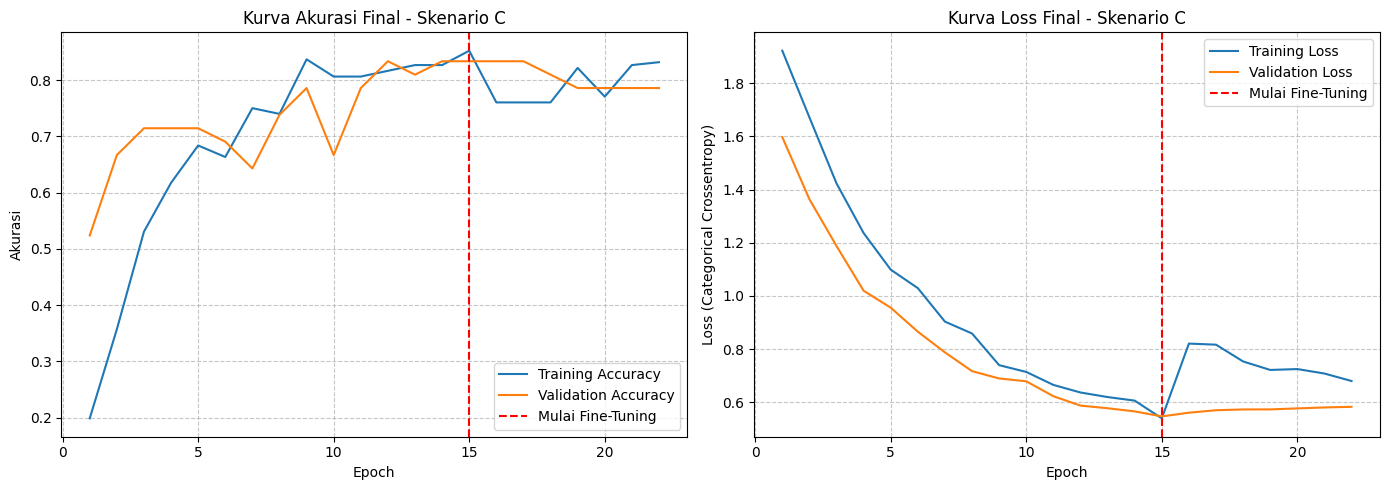

In [6]:
def plot_combined_learning_curves(hist1, hist2, save_dir):
    """
    Menggabungkan history tahap 1 dan tahap 2 ke dalam satu grafik.
    """
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)
    fine_tune_start = len(hist1.history['accuracy'])

    plt.figure(figsize=(14, 5))

    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=fine_tune_start, color='red', linestyle='--', label='Mulai Fine-Tuning')
    plt.title('Kurva Akurasi Final - Skenario C')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=fine_tune_start, color='red', linestyle='--', label='Mulai Fine-Tuning')
    plt.title('Kurva Loss Final - Skenario C')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'scenario_c_learning_curves.png'), dpi=300)
    plt.show()

plot_combined_learning_curves(history_step1, history_fine, OUTPUTS_DIR)

## 6. Pengujian Kinerja Akhir (Testing)
Inilah penentu apakah target >85% dari penelitian skripsi ini tercapai. Kita akan membombardir model terbaik kita dengan data Uji.


🔍 Memuat Model Pamungkas dan Mengevaluasi Data Uji...


🚀 AKURASI AKHIR SKENARIO C : 76.19%

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step

--- CLASSIFICATION REPORT ---
                            precision    recall  f1-score   support

            cataflam_50_mg       0.75      1.00      0.86         6
           cetirizin_10_mg       1.00      0.83      0.91         6
  pantoprazol_sandoz_40_mg       1.00      1.00      1.00         6
     c_vitamin_teva_500_mg       0.00      0.00      0.00         6
      aspirin_ultra_500_mg       1.00      0.50      0.67         6
algoflex_forte_dolo_400_mg       0.60      1.00      0.75         6
    merckformin_xr_1000_mg       0.60      1.00      0.75         6

                  accuracy                           0.76        42
                 macro avg       0.71      0.76      0.70        42
              weighted avg       0.71      0.76      0.70        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


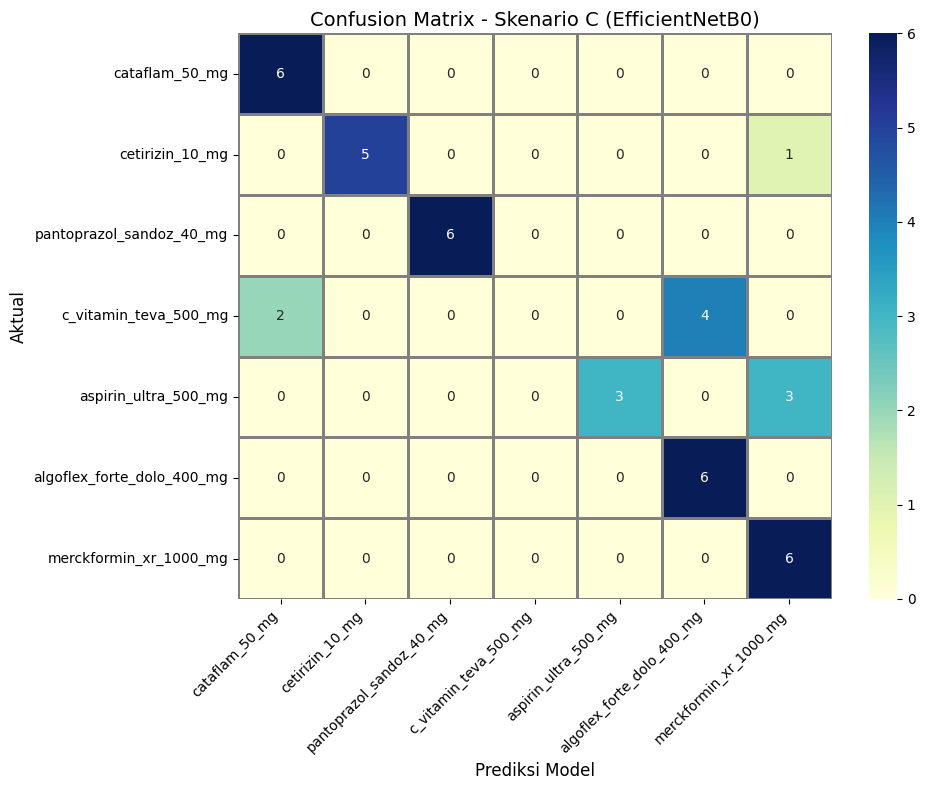

In [7]:
def evaluate_final_model(model_path, test_gen, classes, save_dir):
    """
    Evaluasi puncak untuk Skenario C.
    """
    print("\n🔍 Memuat Model Pamungkas dan Mengevaluasi Data Uji...")
    best_model = tf.keras.models.load_model(model_path)

    test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
    print("========================================")
    print(f"🚀 AKURASI AKHIR SKENARIO C : {test_acc * 100:.2f}%")
    print("========================================\n")

    test_gen.reset()
    predictions = best_model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes

    # Classification Report
    report = classification_report(true_classes, predicted_classes, target_names=classes)
    print("\n--- CLASSIFICATION REPORT ---")
    print(report)

    with open(os.path.join(save_dir, 'scenario_c_classification_report.txt'), 'w') as f:
        f.write(report)

    # Confusion Matrix (Menggunakan warna Biru Tua untuk representasi Profesional)
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=classes, yticklabels=classes,
                linewidths=1, linecolor='gray')

    plt.title('Confusion Matrix - Skenario C (EfficientNetB0)', fontsize=14)
    plt.xlabel('Prediksi Model', fontsize=12)
    plt.ylabel('Aktual', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'scenario_c_confusion_matrix.png'), dpi=300)
    plt.show()

evaluate_final_model(MODEL_SAVE_PATH, test_generator, TARGET_CLASSES, OUTPUTS_DIR)

## ✅ KESIMPULAN FASE 5 (Skenario C)
Luar biasa! Tahap eksekusi dan komputasi terbesar dalam penelitian ini telah usai. Model mutakhir Anda (`scenario_c.h5`) kini tersimpan aman di Google Drive, siap untuk ditarik (*pull*) ke lokal dan dihubungkan dengan UI Streamlit Anda di VSCode.

**Persiapan Akhir (Notebook 5):**
Tahap selanjutnya hanyalah merekap hasil komparasi antara metrik Skenario A, B, dan C ke dalam satu bentuk tabel ringkas untuk memudahkan penulisan naskah BAB IV Anda.